In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.transforms as mtransforms
import matplotlib.colors as mcolors
import seaborn as sns
import colorsys

from matplotlib_inline.backend_inline import set_matplotlib_formats
from matplotlib.ticker import PercentFormatter, MultipleLocator
from matplotlib.patches import Patch
from matplotlib.offsetbox import OffsetImage, AnnotationBbox, HPacker, AnchoredOffsetbox
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from matplotlib import patheffects as pe
from dataclasses import dataclass

import sys
from pathlib import Path
import os

# Add the src directory to Python path
script_dir = Path.cwd()
quantitative_dir = script_dir.parent
src_path = quantitative_dir / 'src'
sys.path.insert(0, str(src_path))

# Change to quantitative directory for proper file paths
os.chdir(quantitative_dir)

# Now import and use the dataloader
from dataloader import load_paper_df
from dataloader import load_most_recent_df
from pareto_utils import compute_pareto_frontier_with_origin, _pareto_indices, compute_pareto_statistics, compute_model_pareto_rankings
from plotting_utils import setup_colors, get_scaffold_hatch, setup_plot_style

In [3]:
model_df, agent_df, benchmark_df = load_paper_df()

# remove models from benchmark_df that are not in model_df or Claude Sonnet 4 or Claude Sonnet 4 High
allowed_models = list(model_df['model']) + ['Claude Sonnet 4', 'Claude Sonnet 4 High']
benchmark_df = benchmark_df[benchmark_df['model'].isin(allowed_models)].copy()
benchmark_df.reset_index(drop=True, inplace=True)

model_df = model_df[model_df['model'].isin(allowed_models)].copy()
model_df.reset_index(drop=True, inplace=True)

# filter out taubench
benchmark_df = benchmark_df[~benchmark_df['benchmark_name'].str.contains('taubench', na=False)].copy()
model_df = model_df[~model_df['benchmark_name'].str.contains('taubench', na=False)].copy()

# Select only top model accuracy for each benchmark
benchmark_df = benchmark_df.sort_values('accuracy', ascending=False).drop_duplicates(subset=['model', 'benchmark_name'])
model_df = model_df.sort_values('accuracy', ascending=False).drop_duplicates(subset=['model', 'benchmark_name'])


Saved plots: benchmark_correlations.png and .pdf


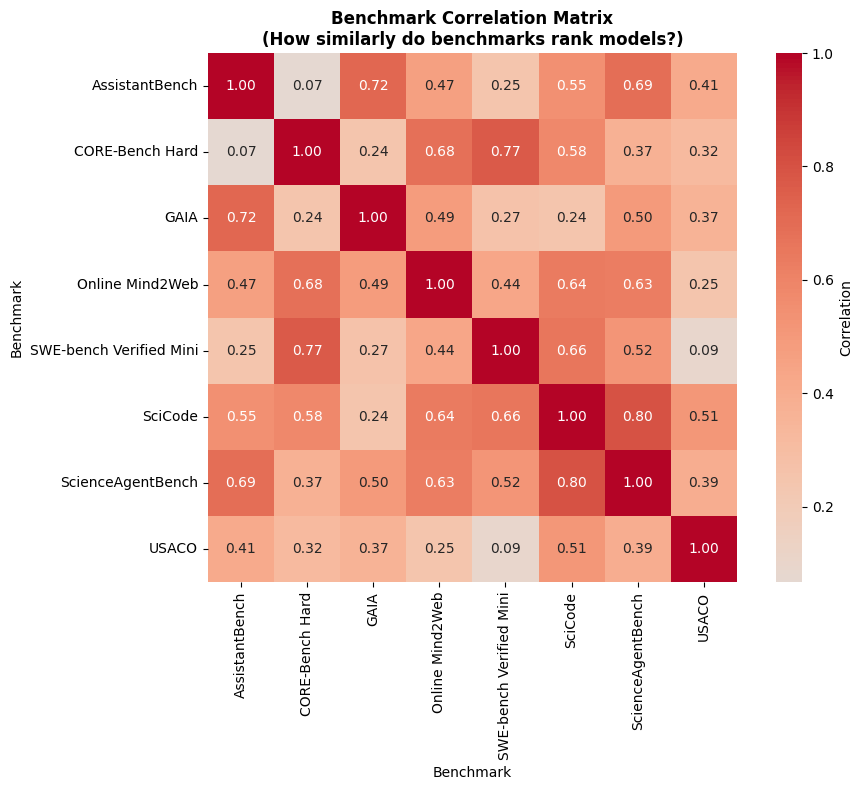

bench_label,AssistantBench,CORE-Bench Hard,GAIA,Online Mind2Web,SWE-bench Verified Mini,SciCode,ScienceAgentBench,USACO
bench_label,,,,,,,,
AssistantBench,1.000000,0.066667,0.721542,0.466667,0.250515,0.545175,0.691385,0.412587
CORE-Bench Hard,0.066667,1.000000,0.244289,0.682940,0.768552,0.577287,0.371687,0.315791
GAIA,0.721542,0.244289,1.000000,0.490909,0.265294,0.242922,0.498246,0.367776
Online Mind2Web,0.466667,0.682940,0.490909,1.000000,0.435616,0.635912,0.628060,0.248485
SWE-bench Verified Mini,0.250515,0.768552,0.265294,0.435616,1.000000,0.663083,0.519910,0.093048
SciCode,0.545175,0.577287,0.242922,0.635912,0.663083,1.000000,0.801791,0.509774
ScienceAgentBench,0.691385,0.371687,0.498246,0.628060,0.519910,0.801791,1.000000,0.391550
USACO,0.412587,0.315791,0.367776,0.248485,0.093048,0.509774,0.391550,1.000000


In [4]:
# Create correlation matrix showing how benchmarks correlate with each other
def create_benchmark_correlation_matrix(df):
    """
    Create a correlation matrix showing how benchmarks correlate with each other
    based on model performance patterns across benchmarks.
    """
    # Filter to required columns and remove any missing data
    corr_df = df[['bench_label', 'model', 'accuracy']].dropna()
    
    # Pivot to create matrix: rows=models, columns=benchmarks
    pivot_df = corr_df.pivot_table(
        index='model', 
        columns='bench_label', 
        values='accuracy', 
        aggfunc='mean'  # Average if multiple entries per model-benchmark
    )
    
    # Calculate correlation between benchmarks (columns)
    # This shows how similar model rankings are between pairs of benchmarks
    correlation_matrix = pivot_df.corr(method='spearman')
    
    return correlation_matrix

# Generate the correlation matrix
benchmark_corr_matrix = create_benchmark_correlation_matrix(benchmark_df)

# Create single correlation matrix plot
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

sns.heatmap(benchmark_corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            square=True,
            cbar_kws={'label': 'Correlation'},
            ax=ax)

ax.set_title('Benchmark Correlation Matrix\n(How similarly do benchmarks rank models?)', fontweight='bold')
ax.set_xlabel('Benchmark')
ax.set_ylabel('Benchmark')

plt.tight_layout()

# Save the plot
output_path = str(quantitative_dir / "plots/")
os.makedirs(output_path, exist_ok=True)
plt.savefig(os.path.join(output_path, "benchmark_correlations.png"), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(output_path, "benchmark_correlations.pdf"), bbox_inches='tight')
print(f"Saved plots: benchmark_correlations.png and .pdf")

plt.show()

benchmark_corr_matrix

In [5]:
print(benchmark_corr_matrix)

bench_label              AssistantBench  CORE-Bench Hard      GAIA  \
bench_label                                                          
AssistantBench                 1.000000         0.066667  0.721542   
CORE-Bench Hard                0.066667         1.000000  0.244289   
GAIA                           0.721542         0.244289  1.000000   
Online Mind2Web                0.466667         0.682940  0.490909   
SWE-bench Verified Mini        0.250515         0.768552  0.265294   
SciCode                        0.545175         0.577287  0.242922   
ScienceAgentBench              0.691385         0.371687  0.498246   
USACO                          0.412587         0.315791  0.367776   

bench_label              Online Mind2Web  SWE-bench Verified Mini   SciCode  \
bench_label                                                                   
AssistantBench                  0.466667                 0.250515  0.545175   
CORE-Bench Hard                 0.682940                 0.768

In [4]:
benchmark_df.columns

Index(['benchmark_name', 'agent_name', 'date', 'run_id', 'successful_tasks',
       'failed_tasks', 'total_cost', 'accuracy', 'prompt_tokens',
       'completion_tokens', 'total_tokens', 'agent_scaffold', 'model',
       'task_type', 'bench_label', 'model_release_date'],
      dtype='object')

In [8]:
# Calculate single summary correlation across all benchmarks
def calculate_overall_benchmark_correlation(correlation_matrix):
    """
    Calculate a single number representing overall correlation between benchmarks.
    Uses the mean of all pairwise correlations (excluding diagonal).
    """
    # Get upper triangle of correlation matrix (excluding diagonal)
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)
    correlations = correlation_matrix.values[mask]
    
    # Calculate mean correlation
    mean_correlation = np.mean(correlations)
    
    return mean_correlation

# Calculate the single correlation number
overall_correlation = calculate_overall_benchmark_correlation(benchmark_corr_matrix)

print(f"Overall benchmark correlation: {overall_correlation:.3f}")
print(f"This represents the average correlation between all pairs of benchmarks.")

overall_correlation

Overall benchmark correlation: 0.461
This represents the average correlation between all pairs of benchmarks.


np.float64(0.4609806418038275)

In [9]:
# Calculate correlations across benchmarks grouped by task_type
def calculate_correlations_by_task_type(df):
    """
    Calculate benchmark correlations within each task_type group.
    """
    # Filter to required columns
    corr_df = df[['bench_label', 'model', 'accuracy', 'task_type']].dropna()
    
    task_type_correlations = {}
    
    # Group by task_type
    for task_type in sorted(corr_df['task_type'].unique()):
        task_df = corr_df[corr_df['task_type'] == task_type]
        
        # Check if we have enough benchmarks to calculate correlations
        unique_benchmarks = task_df['bench_label'].nunique()
        if unique_benchmarks < 2:
            print(f"Task type '{task_type}' has only {unique_benchmarks} benchmark(s), skipping correlation calculation")
            continue
            
        # Pivot to create matrix: rows=models, columns=benchmarks
        pivot_df = task_df.pivot_table(
            index='model', 
            columns='bench_label', 
            values='accuracy', 
            aggfunc='mean'
        )
        
        # Calculate correlation matrix for this task type
        correlation_matrix = pivot_df.corr(method='spearman')
        
        # Calculate overall correlation for this task type
        if len(correlation_matrix) > 1:
            mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)
            correlations = correlation_matrix.values[mask]
            mean_correlation = np.mean(correlations)
            
            task_type_correlations[task_type] = {
                'correlation_matrix': correlation_matrix,
                'mean_correlation': mean_correlation,
                'n_benchmarks': len(correlation_matrix),
                'benchmark_names': list(correlation_matrix.columns)
            }
    
    return task_type_correlations

# Calculate correlations by task type
task_correlations = calculate_correlations_by_task_type(benchmark_df)

# Display results
print("Benchmark Correlations by Task Type:")
print("=" * 50)

for task_type, data in task_correlations.items():
    print(f"\nTask Type: {task_type}")
    print(f"  Benchmarks ({data['n_benchmarks']}): {', '.join(data['benchmark_names'])}")
    print(f"  Mean correlation: {data['mean_correlation']:.3f}")
    print(f"  Correlation matrix:")
    print(data['correlation_matrix'].round(3))
    print("-" * 30)

# Summary comparison
print("\nSummary by Task Type:")
for task_type, data in sorted(task_correlations.items(), key=lambda x: x[1]['mean_correlation'], reverse=True):
    print(f"{task_type}: {data['mean_correlation']:.3f} (n={data['n_benchmarks']} benchmarks)")

task_correlations

Benchmark Correlations by Task Type:

Task Type: Scientific Programming
  Benchmarks (3): CORE-Bench Hard, SciCode, ScienceAgentBench
  Mean correlation: 0.584
  Correlation matrix:
bench_label        CORE-Bench Hard  SciCode  ScienceAgentBench
bench_label                                                   
CORE-Bench Hard              1.000    0.577              0.372
SciCode                      0.577    1.000              0.802
ScienceAgentBench            0.372    0.802              1.000
------------------------------

Task Type: Software Engineering
  Benchmarks (2): SWE-bench Verified Mini, USACO
  Mean correlation: 0.093
  Correlation matrix:
bench_label              SWE-bench Verified Mini  USACO
bench_label                                            
SWE-bench Verified Mini                    1.000  0.093
USACO                                      0.093  1.000
------------------------------

Task Type: Web Assistance
  Benchmarks (3): AssistantBench, GAIA, Online Mind2Web
  Me

{'Scientific Programming': {'correlation_matrix': bench_label        CORE-Bench Hard   SciCode  ScienceAgentBench
  bench_label                                                    
  CORE-Bench Hard           1.000000  0.577287           0.371687
  SciCode                   0.577287  1.000000           0.801791
  ScienceAgentBench         0.371687  0.801791           1.000000,
  'mean_correlation': np.float64(0.5835883010930418),
  'n_benchmarks': 3,
  'benchmark_names': ['CORE-Bench Hard', 'SciCode', 'ScienceAgentBench']},
 'Software Engineering': {'correlation_matrix': bench_label              SWE-bench Verified Mini     USACO
  bench_label                                               
  SWE-bench Verified Mini                 1.000000  0.093048
  USACO                                   0.093048  1.000000,
  'mean_correlation': np.float64(0.09304842103984708),
  'n_benchmarks': 2,
  'benchmark_names': ['SWE-bench Verified Mini', 'USACO']},
 'Web Assistance': {'correlation_matrix': be

In [13]:
# Calculate benchmark correlations for HAL Generalist Agent only
def calculate_hal_generalist_correlations(df):
    """
    Calculate benchmark correlations using only models with agent_scaffold = "HAL Generalist Agent".
    """
    # Filter to HAL Generalist Agent only
    hal_df = df[df['agent_scaffold'] == 'HAL Generalist Agent'].copy()
    
    if hal_df.empty:
        print("No data found for HAL Generalist Agent")
        return None, None
        
    print(f"Found {len(hal_df)} runs with HAL Generalist Agent")
    print(f"Models: {sorted(hal_df['model'].unique())}")
    print(f"Benchmarks: {sorted(hal_df['bench_label'].unique())}")
    
    # Filter to required columns and remove any missing data
    corr_df = hal_df[['bench_label', 'model', 'accuracy']].dropna()
    
    # Pivot to create matrix: rows=models, columns=benchmarks
    pivot_df = corr_df.pivot_table(
        index='model', 
        columns='bench_label', 
        values='accuracy', 
        aggfunc='mean'
    )
    
    print(f"\nPivot table shape: {pivot_df.shape}")
    print("Data coverage (models x benchmarks):")
    print(pivot_df.round(3))
    
    # Calculate correlation between benchmarks
    correlation_matrix = pivot_df.corr()
    
    # Calculate overall correlation
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)
    correlations = correlation_matrix.values[mask]
    mean_correlation = np.mean(correlations)
    
    return correlation_matrix, mean_correlation

# Calculate correlations for HAL Generalist Agent
hal_corr_matrix, hal_mean_correlation = calculate_hal_generalist_correlations(benchmark_df)

if hal_corr_matrix is not None:
    print(f"\nBenchmark Correlation Matrix (HAL Generalist Agent only):")
    print("=" * 60)
    print(hal_corr_matrix.round(3))
    
    print(f"\nOverall benchmark correlation (HAL Generalist Agent): {hal_mean_correlation:.3f}")
    
    # Compare to overall correlation
    if 'overall_correlation' in globals():
        print(f"Overall correlation (all models): {overall_correlation:.3f}")
        print(f"Difference: {hal_mean_correlation - overall_correlation:+.3f}")
else:
    print("Could not calculate correlations for HAL Generalist Agent")

hal_mean_correlation

Found 36 runs with HAL Generalist Agent
Models: ['Claude Opus 4.1', 'Claude Opus 4.1 High', 'Claude-3.7 Sonnet', 'Claude-3.7 Sonnet High', 'DeepSeek R1', 'DeepSeek V3', 'GPT-4.1', 'GPT-5 Medium', 'Gemini 2.0 Flash', 'o3 Medium', 'o4-mini High', 'o4-mini Low']
Benchmarks: ['CORE-Bench (Hard)', 'SWE-bench Verified (Mini)', 'TauBench – Airline']

Pivot table shape: (12, 3)
Data coverage (models x benchmarks):
bench_label             CORE-Bench (Hard)  SWE-bench Verified (Mini)  \
model                                                                  
Claude Opus 4.1                     0.356                       0.42   
Claude Opus 4.1 High                0.333                       0.46   
Claude-3.7 Sonnet                   0.311                       0.26   
Claude-3.7 Sonnet High              0.378                       0.24   
DeepSeek R1                         0.089                       0.06   
DeepSeek V3                         0.089                       0.10   
GPT-4.1       

np.float64(0.6554131446461483)